### Modelling, basic XGBoost

In [31]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import holidays
import matplotlib.pyplot as plt

from matplotlib.patches import Patch
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.model_selection import TimeSeriesSplit, GridSearchCV
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from datetime import datetime
from sklearn.model_selection import train_test_split, TimeSeriesSplit
from xgboost import XGBRegressor
from sklearn import set_config
set_config(display="text")

In [22]:
df = pd.read_csv("data/clean/Cleaned_Sweden_Energy.csv", index_col=0, parse_dates=True)
print(df.shape)
print(df.columns)
df.head()

(31176, 7)
Index(['total_demand', 'forecast', 'Other', 'Hydro Water Reservoir', 'Nuclear',
       'Wind Onshore', 'Solar'],
      dtype='str')


,total_demand,forecast,Other,Hydro Water Reservoir,Nuclear,Wind Onshore,Solar
datetime,,,,,,,
2022-01-01 00:00:00,15331.0,14904.0,1264.88,7015.42,5842.0,4044.65,0.0
2022-01-01 01:00:00,15331.0,14760.0,1273.08,7086.16,5839.0,4021.43,0.0
2022-01-01 02:00:00,15270.0,14678.0,1277.43,7087.87,5839.0,3948.19,0.0
2022-01-01 03:00:00,15150.0,14730.0,1276.73,6745.68,5840.0,3763.19,0.0
2022-01-01 04:00:00,15387.0,14966.0,1301.19,7173.10,5839.0,3597.12,0.0


In [23]:
# Basic time features
df['hour'] = df.index.hour
df['day'] = df.index.day
df['weekday'] = df.index.weekday
df['month'] = df.index.month

# Lag features for total_demand
# Since we are trying to predict day-ahead demand, so we use lags that correspond to 1 day, 2 days, 1 week, 2 weeks, and 1 month.
for lag in [24, 48, 168, 336, 720]:
    df[f'lag_{lag}'] = df['total_demand'].shift(lag)

# Cyclical encodings
df['hour_sin'] = np.sin(2 * np.pi * df['hour'] / 24)
df['hour_cos'] = np.cos(2 * np.pi * df['hour'] / 24)
df['month_sin'] = np.sin(2 * np.pi * df['month'] / 12)
df['month_cos'] = np.cos(2 * np.pi * df['month'] / 12)

# Flags
df['is_weekend'] = df['weekday'].isin([5, 6]).astype(int)
df['is_winter'] = df['month'].isin([12, 1, 2]).astype(int)
df['is_summer'] = df['month'].isin([6, 7, 8]).astype(int)

swedish_holidays = holidays.Sweden(years=[2022, 2023, 2024, 2025])
df['is_holiday'] = df.index.normalize().isin(swedish_holidays).astype(int)

# Rolling statistics
# df['rolling_mean_24'] = df['total_demand'].rolling(window=24).mean()
# df['rolling_std_24'] = df['total_demand'].rolling(window=24).std()
# df['rolling_mean_168'] = df['total_demand'].rolling(window=168).mean()

# Drop rows with any missing values from shifting/rolling
df.dropna(inplace=True)

# drop rolling statistics columns if they exist
# df.drop(
#     columns=['rolling_mean_24', 'rolling_std_24', 'rolling_mean_168'],
#     errors='ignore',
#     inplace=True,
# )

df_forecast = df[['forecast']].copy()

# drop the forecast column if it exists
df.drop(
    columns=['forecast'],
    errors='ignore',
    inplace=True,
)

# Print final checks
print("Shape:", df.shape)
print("Date Range:", df.index.min(), "to", df.index.max())
print("Columns:", df.columns.tolist())
print("Missing values:\n", df.isna().sum())

df.head()

Shape: (30456, 23)
Date Range: 2022-01-31 00:00:00 to 2025-07-22 23:00:00
Columns: ['total_demand', 'Other', 'Hydro Water Reservoir', 'Nuclear', 'Wind Onshore', 'Solar', 'hour', 'day', 'weekday', 'month', 'lag_24', 'lag_48', 'lag_168', 'lag_336', 'lag_720', 'hour_sin', 'hour_cos', 'month_sin', 'month_cos', 'is_weekend', 'is_winter', 'is_summer', 'is_holiday']
Missing values:
 total_demand             0
Other                    0
Hydro Water Reservoir    0
Nuclear                  0
Wind Onshore             0
Solar                    0
hour                     0
day                      0
weekday                  0
month                    0
lag_24                   0
lag_48                   0
lag_168                  0
lag_336                  0
lag_720                  0
hour_sin                 0
hour_cos                 0
month_sin                0
month_cos                0
is_weekend               0
is_winter                0
is_summer                0
is_holiday               0


,total_demand,Other,Hydro Water Reservoir,Nuclear,Wind Onshore,Solar,hour,day,weekday,month,...,lag_336,lag_720,hour_sin,hour_cos,month_sin,month_cos,is_weekend,is_winter,is_summer,is_holiday
datetime,,,,,,,,,,,,,,,,,,,,,
2022-01-31 00:00:00,17116.0,1232.39,8525.39,6960.0,4710.70,0.0,0,31,0,1,...,16828.0,15331.0,0.000000,1.000000,0.5,0.866025,0,1,0,0
2022-01-31 01:00:00,17140.0,1249.15,8626.50,6959.0,4365.90,0.0,1,31,0,1,...,16889.0,15331.0,0.258819,0.965926,0.5,0.866025,0,1,0,0
2022-01-31 02:00:00,17333.0,1291.35,8754.77,6958.0,4087.39,0.0,2,31,0,1,...,16854.0,15270.0,0.500000,0.866025,0.5,0.866025,0,1,0,0
2022-01-31 03:00:00,17328.0,1396.05,9068.57,6957.0,3691.40,0.0,3,31,0,1,...,17271.0,15150.0,0.707107,0.707107,0.5,0.866025,0,1,0,0
2022-01-31 04:00:00,17952.0,1500.99,9601.47,6956.0,3366.40,0.0,4,31,0,1,...,18182.0,15387.0,0.866025,0.500000,0.5,0.866025,0,1,0,0


In [5]:
def run_xgboost_forecast(df, target_column, feature_columns, model_name='Model'):
    X = df[feature_columns]
    y = df[target_column]

    # Train-test split (no shuffle since it's time series)
    X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, shuffle=False)

    # Simple XGBoost model
    model = XGBRegressor(n_estimators=100, learning_rate=0.1, random_state=42)
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)

    # Evaluation
    mae = mean_absolute_error(y_test, y_pred)
    r2 = r2_score(y_test, y_pred)

    print(f"\n{model_name} Results")
    print(f"MAE: {mae:.2f}")
    print(f"R² Score: {r2:.4f}")

    # Plotting
    plt.figure(figsize=(14, 5))
    plt.plot(y_test.index[:200], y_test[:200], label='Actual', linewidth=2)
    plt.plot(y_test.index[:200], y_pred[:200], label='Predicted', linestyle='--')
    plt.title(f'{model_name} — Sample of 200 Hours')
    plt.xlabel('Timestamp')
    plt.ylabel(target_column)
    plt.legend()
    plt.grid(True)
    plt.tight_layout()
    plt.show()

    return model



Total Demand Forecast With Only Time Series Features Results
MAE: 634.96
R² Score: 0.9310


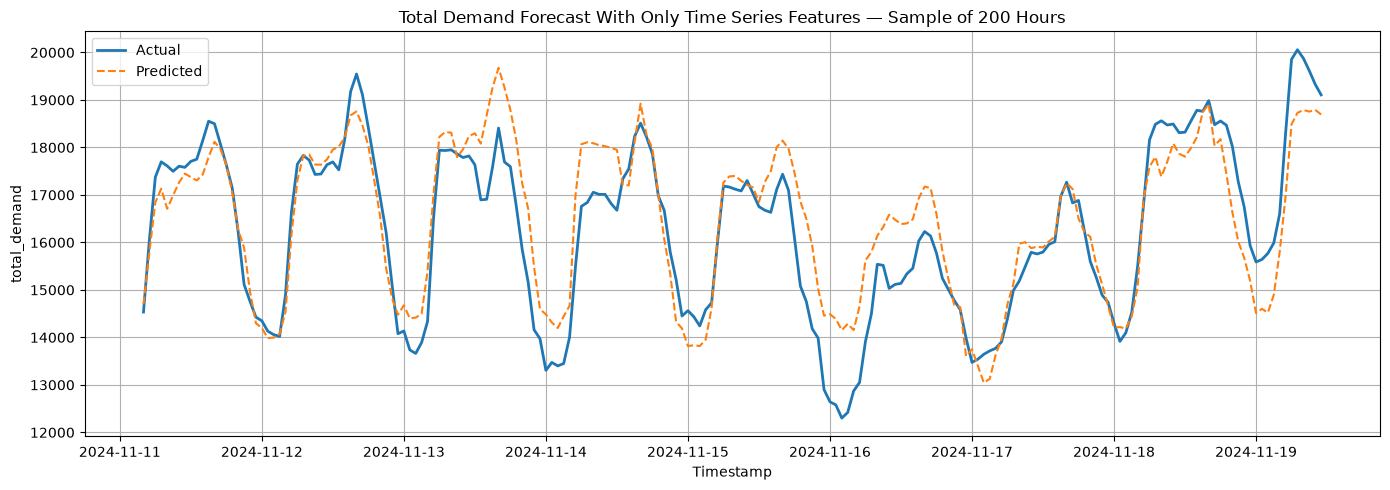

XGBRegressor(base_score=None, booster=None, callbacks=None,
             colsample_bylevel=None, colsample_bynode=None,
             colsample_bytree=None, device=None, early_stopping_rounds=None,
             enable_categorical=True, eval_metric=None, feature_types=None,
             feature_weights=None, gamma=None, grow_policy=None,
             importance_type=None, interaction_constraints=None,
             learning_rate=0.1, max_bin=None, max_cat_threshold=None,
             max_cat_to_onehot=None, max_delta_step=None, max_depth=None,
             max_leaves=None, min_child_weight=None, missing=nan,
             monotone_constraints=None, multi_strategy=None, n_estimators=100,
             n_jobs=None, num_parallel_tree=None, ...)

In [8]:
time_series_features = [
    'hour', 'day', 'weekday', 'month',
    'lag_24', 'lag_48', 'lag_168', 'lag_336', 'lag_720',
    'hour_sin', 'hour_cos',
    'month_sin', 'month_cos',
    'is_weekend', 'is_winter', 'is_summer', 'is_holiday',
]
run_xgboost_forecast(df, target_column='total_demand', feature_columns=time_series_features, model_name='Total Demand Forecast With Only Time Series Features')


Total Demand Forecast With Only Generation Features Results
MAE: 1102.52
R² Score: 0.8093


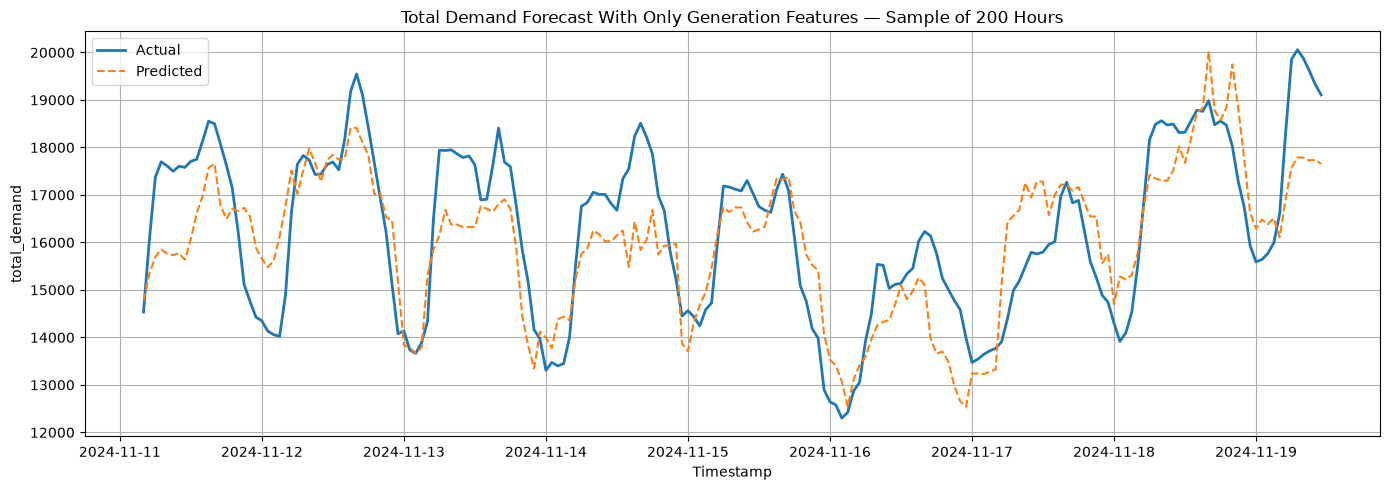

XGBRegressor(base_score=None, booster=None, callbacks=None,
             colsample_bylevel=None, colsample_bynode=None,
             colsample_bytree=None, device=None, early_stopping_rounds=None,
             enable_categorical=True, eval_metric=None, feature_types=None,
             feature_weights=None, gamma=None, grow_policy=None,
             importance_type=None, interaction_constraints=None,
             learning_rate=0.1, max_bin=None, max_cat_threshold=None,
             max_cat_to_onehot=None, max_delta_step=None, max_depth=None,
             max_leaves=None, min_child_weight=None, missing=nan,
             monotone_constraints=None, multi_strategy=None, n_estimators=100,
             n_jobs=None, num_parallel_tree=None, ...)

In [9]:
generation_features = [
    'Other', 'Hydro Water Reservoir', 'Nuclear', 'Wind Onshore', 'Solar',
]
run_xgboost_forecast(df, target_column='total_demand', feature_columns=generation_features, model_name='Total Demand Forecast With Only Generation Features')


Total Demand Forecast With Combined Features Results
MAE: 623.40
R² Score: 0.9331


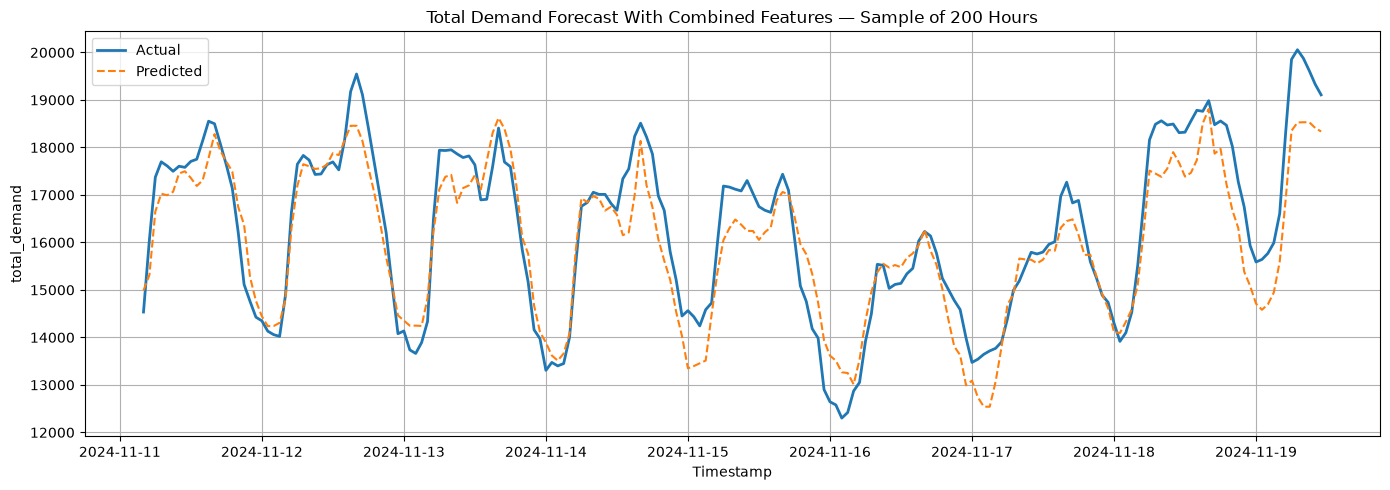

XGBRegressor(base_score=None, booster=None, callbacks=None,
             colsample_bylevel=None, colsample_bynode=None,
             colsample_bytree=None, device=None, early_stopping_rounds=None,
             enable_categorical=True, eval_metric=None, feature_types=None,
             feature_weights=None, gamma=None, grow_policy=None,
             importance_type=None, interaction_constraints=None,
             learning_rate=0.1, max_bin=None, max_cat_threshold=None,
             max_cat_to_onehot=None, max_delta_step=None, max_depth=None,
             max_leaves=None, min_child_weight=None, missing=nan,
             monotone_constraints=None, multi_strategy=None, n_estimators=100,
             n_jobs=None, num_parallel_tree=None, ...)

In [10]:
combined_features = time_series_features + generation_features
run_xgboost_forecast(df, target_column='total_demand', feature_columns=combined_features, model_name='Total Demand Forecast With Combined Features')

In [15]:
#Defining the common function for running the Optuna tuning
def run_optuna_optimization(objective_func, n_trials=30, direction='minimize'): #trials, we can make it maybe 50, its a bit longer
    import optuna
    study = optuna.create_study(direction=direction)
    study.optimize(objective_func, n_trials=n_trials)
    print("Best Score:", study.best_value)
    print("Best Parameters:", study.best_params)
    return study

In [ ]:
# Preparing the train and test data again
# Since we need to tuning the hyperparameters of our model, we will split the data into dev(train and validation) and test sets.
# And we are using the k-fold cross-validation for hyperparameter tuning.
# Since this is a time series problem, so the k-fold should be orderly, and we achieve this by using TimeSeriesSplit.

X = df[combined_features]
y = df['total_demand']

split = int(len(df) * 0.8)

X_dev, X_test = X.iloc[:split], X.iloc[split:]
y_dev, y_test = y.iloc[:split], y.iloc[split:]


In [ ]:
# defining the xgboost part, so the optuna can run for any model, but we are defining xgboost parameters
def xgb_objective(trial, X_dev, y_dev):
    params = {
        'n_estimators': trial.suggest_int('n_estimators', 100, 500),
        'max_depth': trial.suggest_int('max_depth', 3, 15),
        'learning_rate': trial.suggest_float('learning_rate', 0.01, 0.3),
        'subsample': trial.suggest_float('subsample', 0.6, 1.0),
        'colsample_bytree': trial.suggest_float('colsample_bytree', 0.6, 1.0),
        'gamma': trial.suggest_float('gamma', 0, 5),
        'min_child_weight': trial.suggest_int('min_child_weight', 1, 10),
        'random_state': 42
    }

    fold_scores = []

    tscv = TimeSeriesSplit(n_splits=5)

    for train_idx, val_idx in tscv.split(X_dev):
        model = XGBRegressor(**params)

        model.fit(
            X_dev.iloc[train_idx],
            y_dev.iloc[train_idx],
        )

        predictions = model.predict(X_dev.iloc[val_idx])

        fold_scores.append(
            mean_absolute_error(y_dev.iloc[val_idx], predictions)
        )


    return np.mean(fold_scores)

In [18]:
#Running the optimization
study_xgb = run_optuna_optimization(xgb_objective, n_trials=30)
#running the final model with the best parameters we found
best_xgb = XGBRegressor(**study_xgb.best_params, random_state=42)
best_xgb.fit(X_dev, y_dev)
#Lets see if it worked

y_pred_best = best_xgb.predict(X_test)

mae = mean_absolute_error(y_test, y_pred_best)
r2 = r2_score(y_test, y_pred_best)

print(f"MAE: {mae:.2f}")
print(f"R² Score: {r2:.4f}")

[I 2026-09-21 00:26:06,571] A new study created in memory with name: no-name-b1c67493-1ae4-4fdd-a9d2-ed19f0250108
[I 2026-09-21 00:26:24,076] Trial 0 finished with value: 665.9814685671952 and parameters: {'n_estimators': 118, 'max_depth': 14, 'learning_rate': 0.18279551223332247, 'subsample': 0.6517777378255049, 'colsample_bytree': 0.9538075658436147, 'gamma': 2.8537489704352206, 'min_child_weight': 1}. Best is trial 0 with value: 665.9814685671952.
[I 2026-09-21 00:26:41,095] Trial 1 finished with value: 666.5640431149939 and parameters: {'n_estimators': 489, 'max_depth': 9, 'learning_rate': 0.20756832618880125, 'subsample': 0.7240388131768971, 'colsample_bytree': 0.7359609586540833, 'gamma': 3.2148202193984092, 'min_child_weight': 9}. Best is trial 0 with value: 665.9814685671952.
[I 2026-09-21 00:26:49,702] Trial 2 finished with value: 702.8176025323276 and parameters: {'n_estimators': 168, 'max_depth': 13, 'learning_rate': 0.27738304844408335, 'subsample': 0.6163508497763138, 'col

Best Score: 614.8609623633776
Best Parameters: {'n_estimators': 195, 'max_depth': 7, 'learning_rate': 0.03938902904294467, 'subsample': 0.7491146236996464, 'colsample_bytree': 0.7949576331915704, 'gamma': 1.8058671392578625, 'min_child_weight': 9}
MAE: 620.78
R² Score: 0.9332


In [36]:
X_ts = df[time_series_features]
y = df['total_demand']

split = int(len(df) * 0.8)

X_ts_dev, X_ts_test = X_ts.iloc[:split], X_ts.iloc[split:]
y_dev, y_test = y.iloc[:split], y.iloc[split:]

# Use time-series features in the existing objective
X_dev = X_ts_dev

# Start a new tuning study
study_ts = run_optuna_optimization(
    xgb_objective,
    n_trials=30,
)

# Retrain with the best parameters on all development data
best_xgb_ts = XGBRegressor(
    **study_ts.best_params,
    random_state=42,
)
best_xgb_ts.fit(X_ts_dev, y_dev)

# Evaluate on the test period
y_pred_ts = best_xgb_ts.predict(X_ts_test)

print("Best validation MAE:", study_ts.best_value)
print("Test MAE:", mean_absolute_error(y_test, y_pred_ts))
print("Test R²:", r2_score(y_test, y_pred_ts))

[I 2026-09-21 09:05:01,676] A new study created in memory with name: no-name-f8bb9d98-5211-4384-be0d-c1f17aa79480
[I 2026-09-21 09:05:20,257] Trial 0 finished with value: 692.4729909655941 and parameters: {'n_estimators': 467, 'max_depth': 14, 'learning_rate': 0.18514126224663904, 'subsample': 0.6250829640019365, 'colsample_bytree': 0.7783200708508086, 'gamma': 2.621459228319838, 'min_child_weight': 10}. Best is trial 0 with value: 692.4729909655941.
[I 2026-09-21 09:05:40,982] Trial 1 finished with value: 667.1097737299876 and parameters: {'n_estimators': 436, 'max_depth': 15, 'learning_rate': 0.16014458158925715, 'subsample': 0.8869167209847006, 'colsample_bytree': 0.957546952411689, 'gamma': 2.9357061724054043, 'min_child_weight': 7}. Best is trial 1 with value: 667.1097737299876.
[I 2026-09-21 09:05:50,534] Trial 2 finished with value: 688.7326771570966 and parameters: {'n_estimators': 110, 'max_depth': 15, 'learning_rate': 0.02369746474806303, 'subsample': 0.623225870981951, 'cols

Best Score: 618.4526964247228
Best Parameters: {'n_estimators': 345, 'max_depth': 3, 'learning_rate': 0.03972272047231845, 'subsample': 0.87291800152708, 'colsample_bytree': 0.862137152519656, 'gamma': 0.24223641367721033, 'min_child_weight': 4}
Best validation MAE: 618.4526964247228
Test MAE: 638.3810201583532
Test R²: 0.9296467948518758


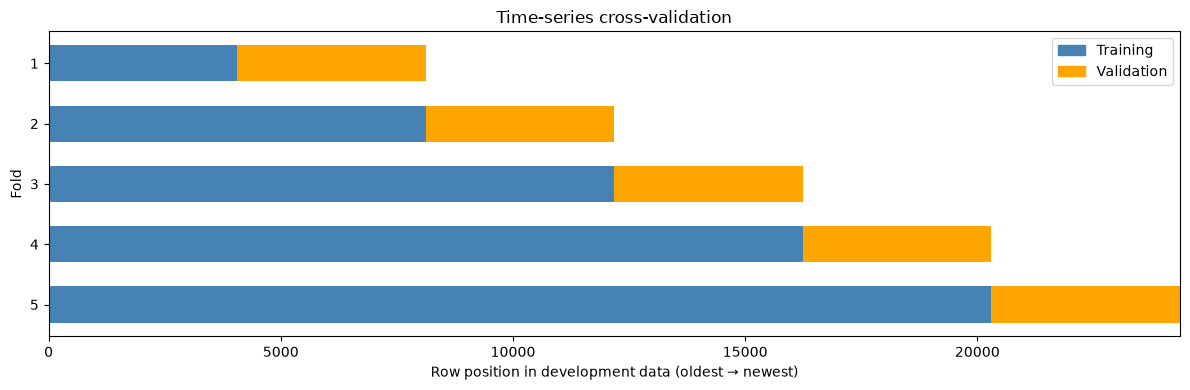

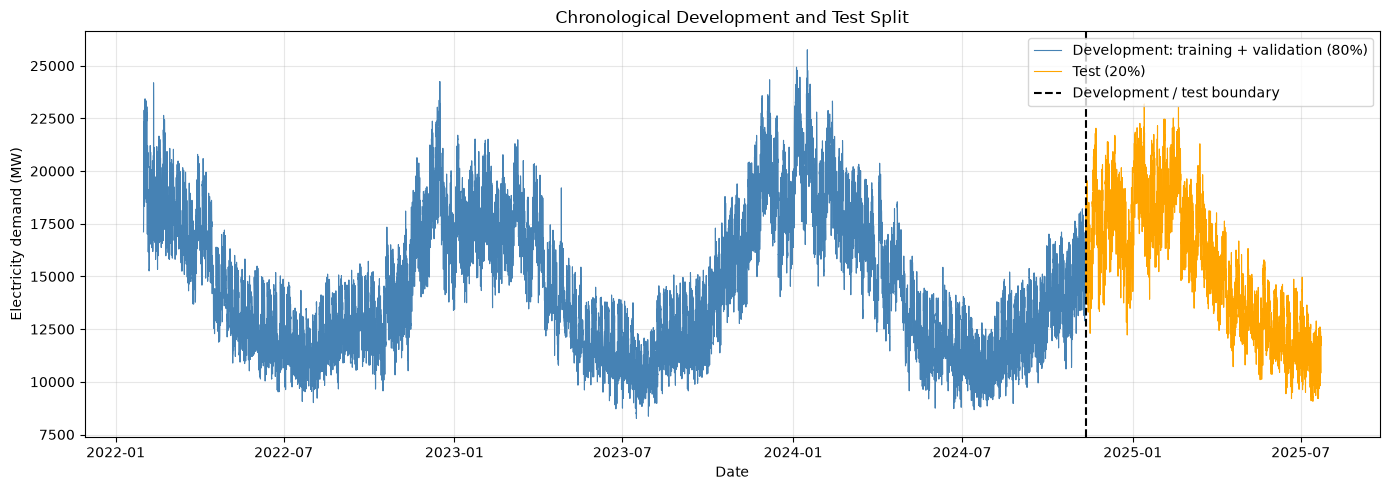

In [33]:
tscv = TimeSeriesSplit(n_splits=5)
fig, ax = plt.subplots(figsize=(12, 4))

for fold, (train_idx, val_idx) in enumerate(tscv.split(X_dev), start=1):
    ax.broken_barh(
        [(train_idx[0], len(train_idx))],
        (fold - 0.3, 0.6),
        facecolors='steelblue',
    )
    ax.broken_barh(
        [(val_idx[0], len(val_idx))],
        (fold - 0.3, 0.6),
        facecolors='orange',
    )

ax.set(
    xlabel='Row position in development data (oldest → newest)',
    ylabel='Fold',
    title='Time-series cross-validation',
    yticks=range(1, 6),
    xlim=(0, len(X_dev)),
)
ax.invert_yaxis()
ax.legend(handles=[
    Patch(color='steelblue', label='Training'),
    Patch(color='orange', label='Validation'),
])
plt.tight_layout()
plt.show()

fig, ax = plt.subplots(figsize=(14, 5))

ax.plot(y_dev.index, y_dev,
        color='steelblue', label='Development: training + validation (80%)',
        linewidth=0.8)

ax.plot(y_test.index, y_test,
        color='orange', label='Test (20%)',
        linewidth=0.8)

ax.axvline(y_test.index[0], color='black', linestyle='--',
           label='Development / test boundary')

ax.set(
    title='Chronological Development and Test Split',
    xlabel='Date',
    ylabel='Electricity demand (MW)',
)
ax.legend()
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

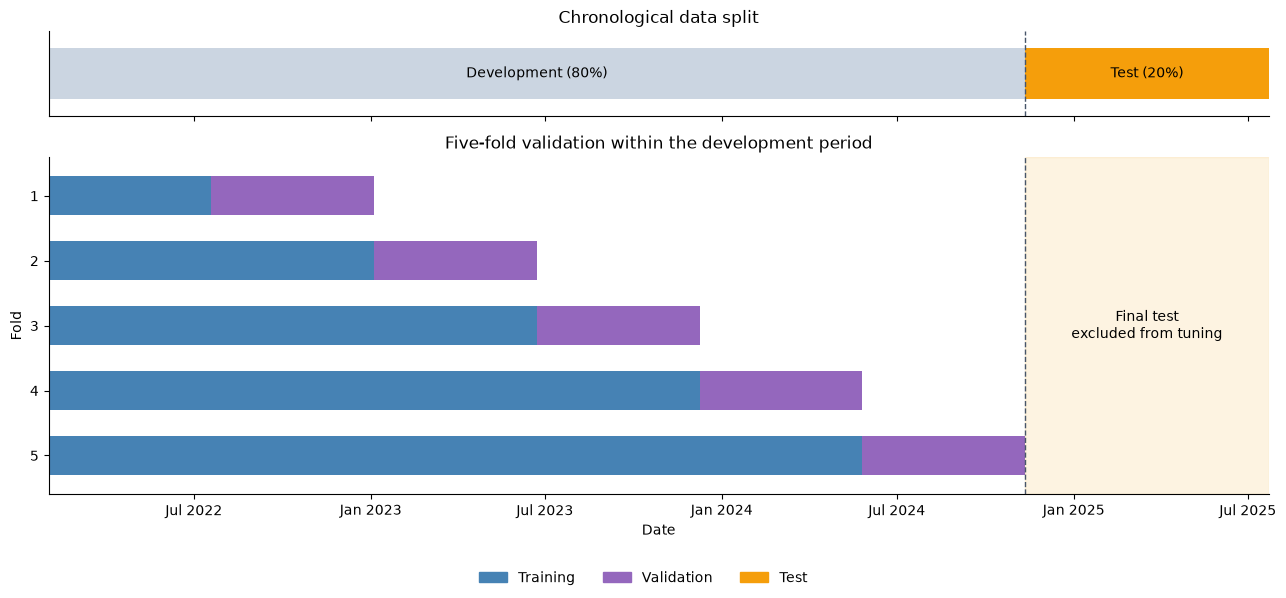

In [35]:
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
from matplotlib.patches import Patch
from sklearn.model_selection import TimeSeriesSplit

colors = {
    'development': '#CBD5E1',
    'training': '#4682B4',
    'validation': '#9467BD',
    'test': '#F59E0B',
}

# Convert timestamps to Matplotlib date coordinates.
dates = X_dev.index.append(X_test.index)
edges = mdates.date2num(
    dates.append(pd.DatetimeIndex([dates[-1] + pd.Timedelta(hours=1)]))
)

n_dev = len(X_dev)
start, boundary, end = edges[0], edges[n_dev], edges[-1]

def draw_bar(ax, first, stop, row, color):
    ax.broken_barh(
        [(edges[first], edges[stop] - edges[first])],
        (row - 0.3, 0.6),
        facecolors=color,
    )

tscv = TimeSeriesSplit(n_splits=5)

fig, (ax_top, ax_cv) = plt.subplots(
    2, 1, figsize=(13, 6), sharex=True,
    gridspec_kw={'height_ratios': [1, 4]},
)

# Overall split
draw_bar(ax_top, 0, n_dev, 0.5, colors['development'])
draw_bar(ax_top, n_dev, len(dates), 0.5, colors['test'])

ax_top.text(
    (start + boundary) / 2, 0.5, 'Development (80%)',
    ha='center', va='center',
)
ax_top.text(
    (boundary + end) / 2, 0.5, 'Test (20%)',
    ha='center', va='center',
)
ax_top.set(ylim=(0, 1), yticks=[], title='Chronological data split')

# Validation folds
for fold, (train_idx, val_idx) in enumerate(tscv.split(X_dev), start=1):
    draw_bar(
        ax_cv, train_idx[0], train_idx[-1] + 1,
        fold, colors['training'],
    )
    draw_bar(
        ax_cv, val_idx[0], val_idx[-1] + 1,
        fold, colors['validation'],
    )

ax_cv.axvspan(boundary, end, color=colors['test'], alpha=0.12)
ax_cv.text(
    (boundary + end) / 2, 3,
    'Final test\nexcluded from tuning',
    ha='center', va='center',
)

ax_cv.set(
    title='Five-fold validation within the development period',
    xlabel='Date',
    ylabel='Fold',
    yticks=range(1, 6),
    xlim=(start, end),
    ylim=(5.6, 0.4),
)

locator = mdates.AutoDateLocator(minticks=5, maxticks=9)
ax_cv.xaxis.set_major_locator(locator)
ax_cv.xaxis.set_major_formatter(mdates.DateFormatter('%b %Y'))

for ax in (ax_top, ax_cv):
    ax.axvline(boundary, color='#475569', linestyle='--', linewidth=1)
    ax.spines[['top', 'right']].set_visible(False)

fig.legend(
    handles=[
        Patch(color=colors['training'], label='Training'),
        Patch(color=colors['validation'], label='Validation'),
        Patch(color=colors['test'], label='Test'),
    ],
    loc='lower center', ncol=3, frameon=False,
)

plt.tight_layout(rect=(0, 0.07, 1, 1))
plt.show()

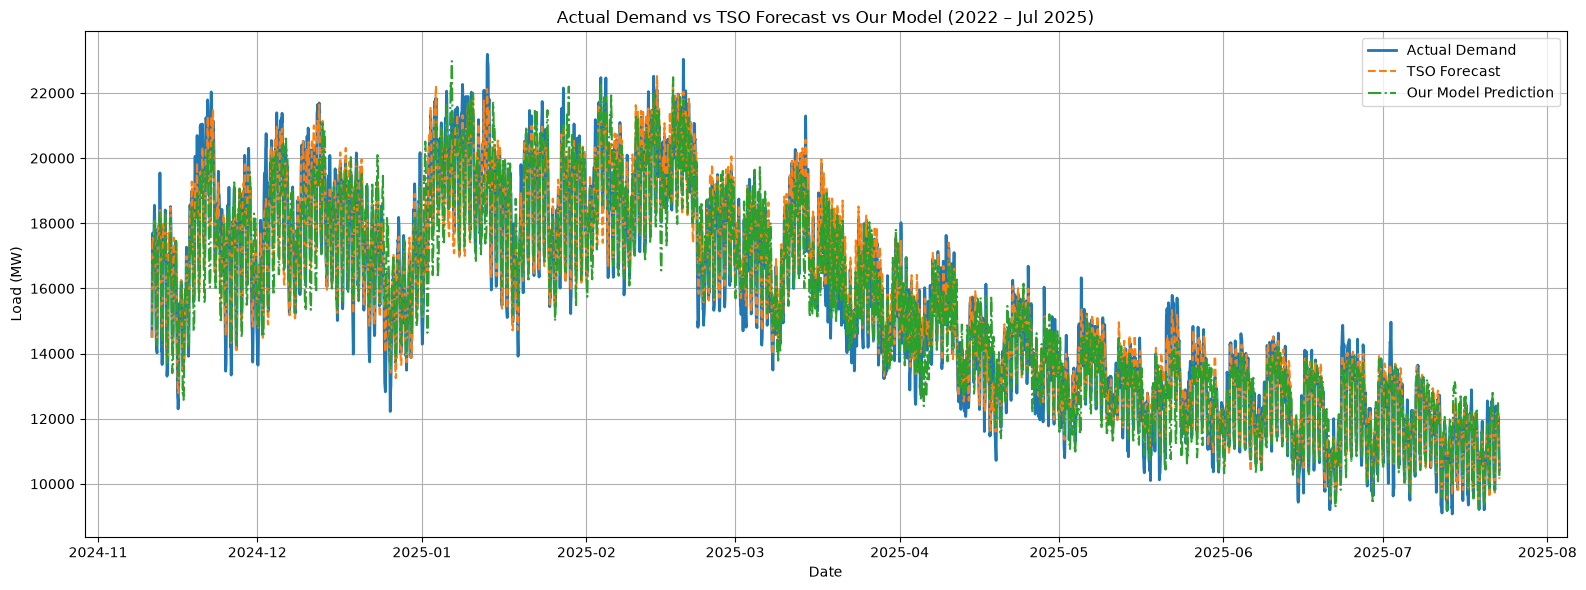

       Model   MAE (MW)       R²
TSO Forecast 409.046454 0.971753
   Our Model 620.780073 0.933152


In [29]:
split = int(len(df) * 0.8)

df_forecast_test = df_forecast.iloc[split:].copy()

# --- Plot comparison ---
plt.figure(figsize=(16, 6))
plt.plot(y_test.index, y_test, label='Actual Demand', linewidth=2)
plt.plot(y_test.index, df_forecast_test['forecast'], label='TSO Forecast', linestyle='--')
plt.plot(y_test.index, y_pred_best, label='Our Model Prediction', linestyle='-.')
plt.title('Actual Demand vs TSO Forecast vs Our Model (2022 – Jul 2025)')
plt.xlabel('Date')
plt.ylabel('Load (MW)')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

comparison = pd.DataFrame({
    'Model': ['TSO Forecast', 'Our Model'],
    'MAE (MW)': [
        mean_absolute_error(y_test, df_forecast_test['forecast']),
        mean_absolute_error(y_test, y_pred_best),
    ],
    'R²': [
        r2_score(y_test, df_forecast_test['forecast']),
        r2_score(y_test, y_pred_best),
    ],
})

print(comparison.to_string(index=False))